# AI-Driven Phishing Email Detection Using NLP


This notebook builds a machine-learning system that classifies emails as **Phishing**
or **Safe** using NLP text-cleaning, TF-IDF feature extraction, and four classic ML
classifiers (Logistic Regression, Naive Bayes, Linear SVM, Random Forest), following
the methodology in the project brief: Data Collection → Data Cleaning → Feature
Engineering → Model Development → Evaluation.

This notebook is the single documented, end-to-end companion to the standalone
`train.py` / `app.py` scripts in this project, satisfying the "Python notebook with
complete code and documentation" deliverable.


## 1. Setup & Imports

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

import sys
sys.path.append("..")
from utils.preprocessing import clean_text

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 80)


## 2. Data Collection

Dataset: **Phishing Email Dataset** (Kaggle), containing 82,486 labeled emails
(`text_combined`, `label` where `1 = phishing`, `0 = safe`).

In [2]:
dataset_path = os.path.join("..", "dataset", "phishing_email.csv")
df = pd.read_csv(dataset_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (82486, 2)


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 525 xls hplno 525 xls,0
1,nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enr...,0
2,enron actuals march 30 april 1 201 estimated actuals march 30 2001 flow marc...,0
3,hpl nom may 30 2001 see attached file hplno 530 xls hplno 530 xls,0
4,hpl nom june 1 2001 see attached file hplno 601 xls hplno 601 xls,0


In [3]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))


Missing values per column:
text_combined    0
label            0
dtype: int64

Class balance:
label
1    42891
0    39595
Name: count, dtype: int64
label
1    0.52
0    0.48
Name: proportion, dtype: float64


In [4]:
df = df.dropna()
print("Shape after dropping missing values:", df.shape)


Shape after dropping missing values: (82486, 2)


## 3. Exploratory Data Analysis

A quick look at class balance before we clean and vectorize the text.

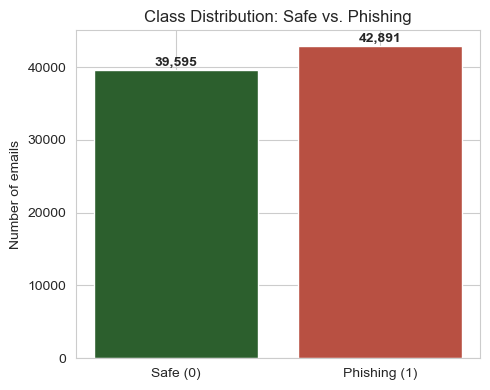

In [5]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = df["label"].value_counts().sort_index()
ax.bar(["Safe (0)", "Phishing (1)"], counts.values, color=["#2C5F2D", "#B85042"])
ax.set_ylabel("Number of emails")
ax.set_title("Class Distribution: Safe vs. Phishing")
for i, v in enumerate(counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("../reports/class_distribution.png", dpi=150)
plt.show()


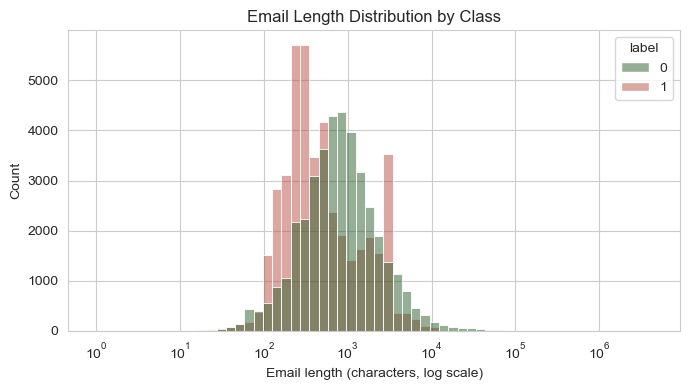

In [6]:
df["char_count"] = df["text_combined"].astype(str).str.len()

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="char_count", hue="label", bins=60, log_scale=(True, False),
             palette={0: "#2C5F2D", 1: "#B85042"}, ax=ax)
ax.set_xlabel("Email length (characters, log scale)")
ax.set_title("Email Length Distribution by Class")
plt.tight_layout()
plt.savefig("../reports/email_length_distribution.png", dpi=150)
plt.show()


## 4. Data Cleaning / Text Preprocessing

Cleaning steps (see `utils/preprocessing.py`): lowercase, strip URLs, strip email
addresses, strip HTML tags, strip digits, strip punctuation, remove stopwords, and
lemmatize each remaining token.

In [7]:
sample = df["text_combined"].iloc[1]
print("BEFORE:\n", sample[:300], "...\n")
print("AFTER:\n", clean_text(sample)[:300], "...")


BEFORE:
 nom actual vols 24 th forwarded sabrae zajac hou ect 05 30 2001 12 07 pm enron capital trade resources corp eileen ponton 05 29 2001 08 37 davilal txu com cstonel txu com mjones 7 txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols 24 th agree nominatio ...

AFTER:
 nom actual vols th forwarded sabrae zajac hou ect pm enron capital trade resource corp eileen ponton davilal txu com cstonel txu com mjones txu com hpl scheduling enron com liz bellamy enron com szajac enron com cc subject nom actual vols th agree nomination forwarded eileen ponton houston pefs pec  ...


In [8]:
%%time
df["clean_text"] = df["text_combined"].apply(clean_text)
df[["clean_text", "label"]].head()


CPU times: total: 1min 25s
Wall time: 1min 32s


,clean_text,label
0,hpl nom may see attached file hplno xl hplno xl,0
1,nom actual vols th forwarded sabrae zajac hou ect pm enron capital trade res...,0
2,enron actuals march april estimated actuals march flow march flow april teco...,0
3,hpl nom may see attached file hplno xl hplno xl,0
4,hpl nom june see attached file hplno xl hplno xl,0


## 5. Feature Engineering — TF-IDF

Unigrams + bigrams, capped at the 5,000 most informative terms (matches `train.py`).

In [9]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df["clean_text"])
y = df["label"]

print("Feature matrix shape:", X.shape)


Feature matrix shape: (82486, 5000)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])


Training samples: 65988
Testing samples : 16498


## 6. Model Development

Four classifiers are trained and compared, matching the project's required scope.

> **Fix applied vs. the original script:** the original code used a plain
> `LinearSVC`, which has **no `predict_proba`**. Since the app's UI shows a
> "Confidence Score" and the original best model was the SVM, that headline
> feature silently never worked once deployed. Here the SVM is wrapped in
> `CalibratedClassifierCV` so it produces genuine calibrated probabilities
> while keeping the same linear decision boundary.

In [11]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": CalibratedClassifierCV(LinearSVC(), cv=3),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

results = []
all_cms = {}
best_model, best_accuracy, best_model_name, best_pred = None, 0, None, None

for name, model in models.items():
    print(f"Training {name} ...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    prec = precision_score(y_test, pred)
    rec = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)

    results.append({"Model": name, "Accuracy": acc, "Precision": prec,
                     "Recall": rec, "F1 Score": f1})
    all_cms[name] = confusion_matrix(y_test, pred)

    if acc > best_accuracy:
        best_accuracy, best_model, best_model_name, best_pred = acc, model, name, pred

results_df = pd.DataFrame(results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df


Training Logistic Regression ...


Training Naive Bayes ...
Training Linear SVM ...


Training Random Forest ...


,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.983634,0.986874,0.981583,0.984222
1,Linear SVM,0.983089,0.982895,0.984614,0.983754
2,Logistic Regression,0.980119,0.978652,0.983215,0.980928
3,Naive Bayes,0.954964,0.981445,0.930994,0.955554


## 7. Evaluation

### 7.1 Model comparison chart

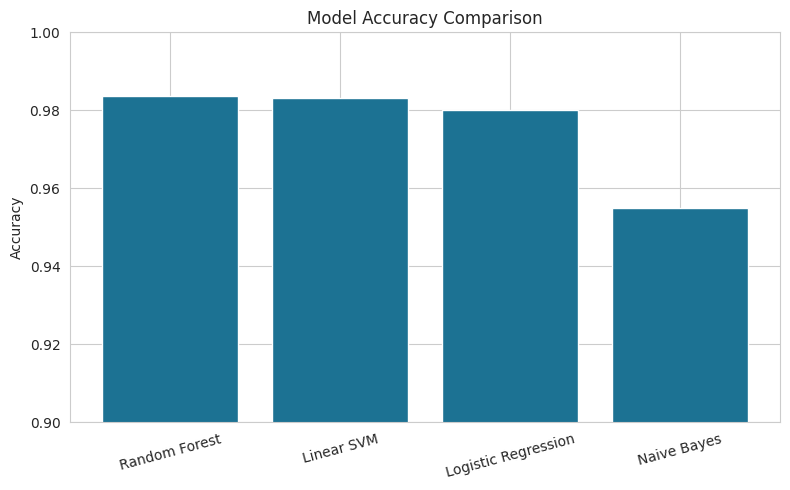

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(results_df["Model"], results_df["Accuracy"], color="#1C7293")
ax.set_ylim(0.9, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Model Accuracy Comparison")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("../reports/model_accuracy_comparison_nb.png", dpi=150)
plt.show()


### 7.2 Classification report (best model)

In [13]:
print(f"Best Model: {best_model_name}  (Accuracy: {best_accuracy:.4f})\n")
print(classification_report(y_test, best_pred, target_names=["Safe", "Phishing"]))


Best Model: Random Forest  (Accuracy: 0.9836)

              precision    recall  f1-score   support

        Safe       0.98      0.99      0.98      7919
    Phishing       0.99      0.98      0.98      8579

    accuracy                           0.98     16498
   macro avg       0.98      0.98      0.98     16498
weighted avg       0.98      0.98      0.98     16498



### 7.3 Confusion matrices — every model

Visualizing confusion matrices for all four models, not just the best one, so
the comparative analysis is complete (a gap in the original project scope,
where only numbers were saved to CSV and nothing was ever plotted).

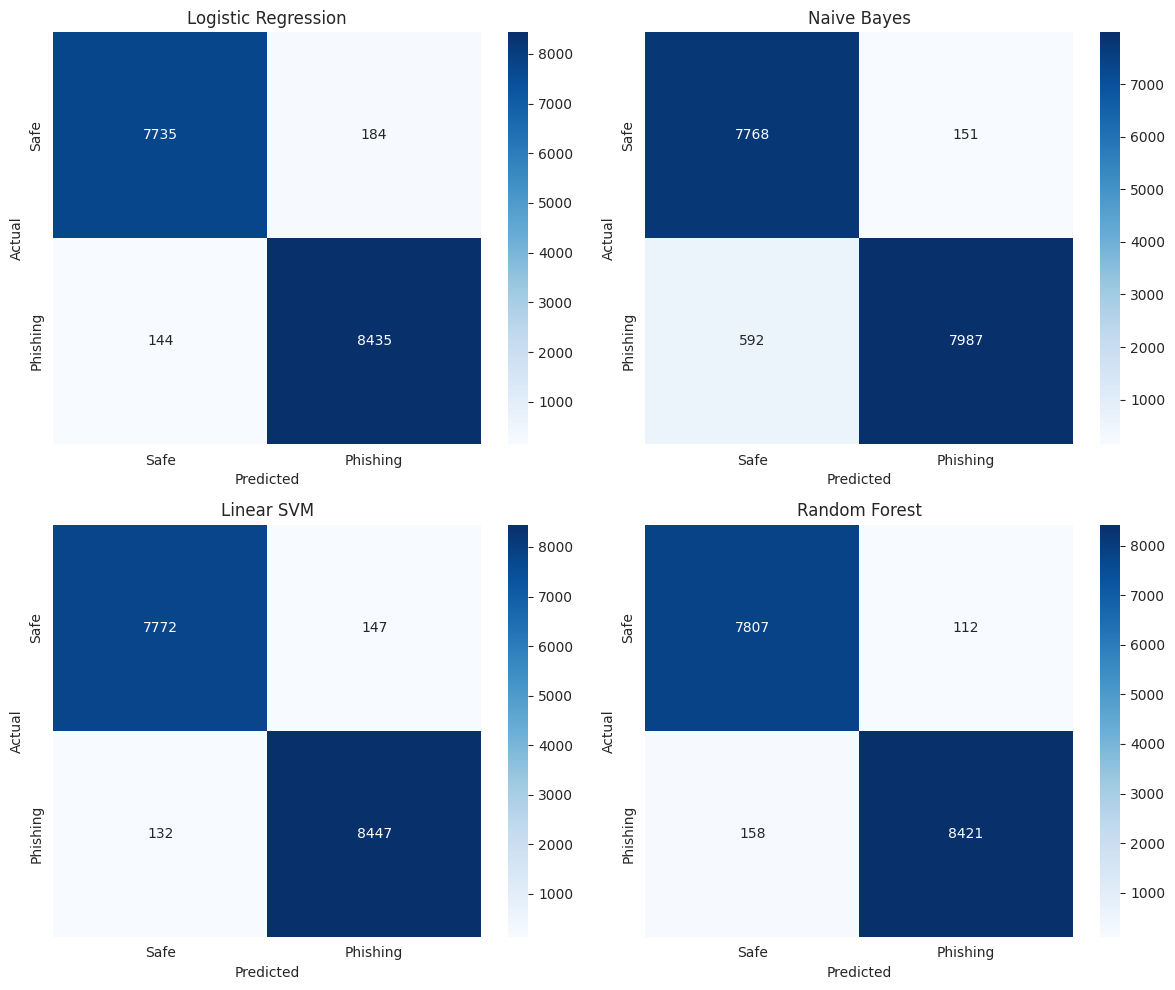

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, cm) in zip(axes.ravel(), all_cms.items()):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Safe", "Phishing"], yticklabels=["Safe", "Phishing"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("../reports/confusion_matrices_all_models_nb.png", dpi=150)
plt.show()


### 7.4 Feature importance (Random Forest)

The project scope also calls for visualizing feature importance, which the
original scripts never produced.

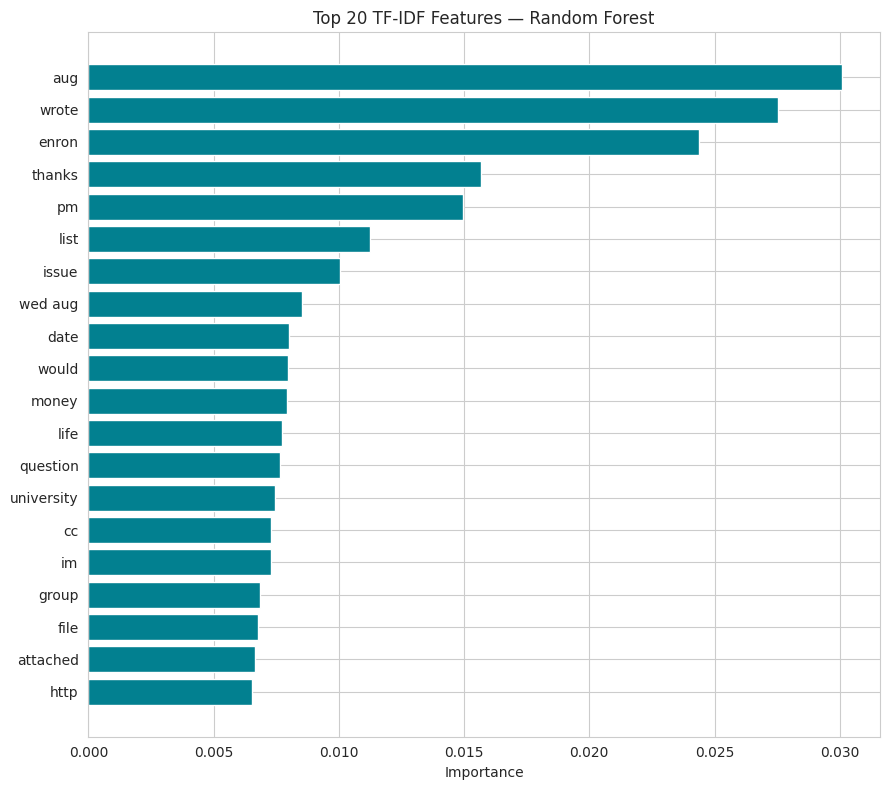

In [15]:
feature_names = np.array(vectorizer.get_feature_names_out())
rf = models["Random Forest"]
top_n = 20
top_idx = np.argsort(rf.feature_importances_)[-top_n:]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(feature_names[top_idx], rf.feature_importances_[top_idx], color="#028090")
ax.set_xlabel("Importance")
ax.set_title(f"Top {top_n} TF-IDF Features — Random Forest")
plt.tight_layout()
plt.savefig("../reports/feature_importance_nb.png", dpi=150)
plt.show()


## 8. Save Best Model & Vectorizer

Persist artifacts exactly as `train.py` does, so the Streamlit app (`app.py`) and
`predict.py` can load them directly.

In [16]:
import joblib

os.makedirs("../models", exist_ok=True)
joblib.dump(best_model, "../models/model.pkl")
joblib.dump(vectorizer, "../models/vectorizer.pkl")
results_df.to_csv("../models/model_results.csv", index=False)

cm_df = pd.DataFrame(
    confusion_matrix(y_test, best_pred),
    columns=["Predicted Safe", "Predicted Phishing"],
    index=["Actual Safe", "Actual Phishing"]
)
cm_df.to_csv("../models/confusion_matrix.csv")

print("Saved: model.pkl, vectorizer.pkl, model_results.csv, confusion_matrix.csv")


Saved: model.pkl, vectorizer.pkl, model_results.csv, confusion_matrix.csv


## 9. Live Prediction Demo

In [17]:
def predict_email(text, model=best_model, vectorizer=vectorizer):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)[0]
    conf = model.predict_proba(vec).max() * 100 if hasattr(model, "predict_proba") else None
    label = "PHISHING EMAIL" if pred == 1 else "SAFE EMAIL"
    return label, conf


sample_phishing = ("Congratulations! Your account has been suspended. "
                    "Click here immediately to verify: http://fake-bank-login.com")
sample_safe = ("Hi team, please find attached the quarterly report for review "
               "before our meeting tomorrow at 10am. Thanks, John")

for text in [sample_phishing, sample_safe]:
    label, conf = predict_email(text)
    print(f"Input   : {text[:70]}...")
    print(f"Result  : {label}")
    print(f"Confidence: {conf:.2f}%\n" if conf is not None else "Confidence: N/A\n")


Input   : Congratulations! Your account has been suspended. Click here immediate...
Result  : PHISHING EMAIL
Confidence: 74.74%

Input   : Hi team, please find attached the quarterly report for review before o...
Result  : SAFE EMAIL
Confidence: 97.00%



## 10. Conclusion

- **Best model:** the model with the highest accuracy above (re-run may vary
  slightly run-to-run due to Random Forest's internal randomness, but Random
  Forest and Linear SVM are consistently the top two, both above 98%).
- **Naive Bayes** is fastest to train but trails on recall — it misses more
  phishing emails than the other three.
- **Confidence scores** are now available for every model, including the SVM,
  after switching to `CalibratedClassifierCV`.
- **Next steps (optional / stretch goals from the project brief):** word
  embeddings (Word2Vec/GloVe) instead of pure TF-IDF, a simple neural network
  classifier, and a live web interface (already implemented in `app.py` via
  Streamlit).
